<a href="https://colab.research.google.com/github/thomashooks53/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

##**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

    - A model is “linear” if it is linear in its coefficients, not in the input variables. That means each coefficient multiplies a term and they are added together, with no coefficients multiplied by each other or inside nonlinear functions.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

    - The coefficient represents the difference in the predicted outcome compared to the reference category, holding all other variables constant. The intercept corresponds to the baseline group, so the dummy variable coefficient shows how much you add or subtract from that baseline when the dummy equals 1.

3. Can linear regression be used for classification? Explain why, or why not.

    - Yes, but it doesn't work very well. Linear regression can produce predictions outside the range [0,1], which don't make sense as probabilities. It also assumes constant variance and normally distributed errors, which isn't usuallt the case in classification problems. That's why methods like logistic regression are preferred.

4. What are signs that your linear model is over-fitting?

    - Overfitting is indicated when the model performs very well on training data but poorly on test data. Other signs include very large coefficients, high sensitivity to small changes in data, and capturing noise rather than true patterns.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

    - Multicollinearity occurs when one predictor can be closely explained by other predictors, making it hard to isolate its effect. In a two-stage idea:
      - First, regress the problematic variable on the others to see how predictable it is.
      - If it is highly predictable, then in the second stage, its unique variation (what’s left after removing overlap) is very small, so its coefficient becomes unstable and hard to estimate reliably.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

    - You can include transformed or engineered features such as polynomial terms (e.g., $x$<sup>2</sup>), interaction terms (e.g., $x$<sub>1</sub>$x$<sub>2</sub>), or functions like logs or exponentials. Even though the relationship in $x$ is nonlinear, the model remains linear in coefficients.

7. What is the interpretation of the slope coefficient in a linear regression?

    - The slope coefficient represents the expected change in the response variable $y$ for a one-unit increase in the predictor, holding all other variables constant.

8. Compare the train/test split and $k$-fold cross validation.

    - Train/test split: Simple and fast; data is split once into training and testing sets. However, results can depend heavily on how the split is done.
    - $k$-fold cross-validation: Data is split into $k$ parts, and the model is trained/tested multiple times. This gives a more reliable estimate of performance but is more computationally expensive.

9. How is the $k$ in $k$-fold cross validation typically selected?

    - Choosing $k$ is a trade-off between time and accuracy. If $k$ is too small, you aren't using enough data to get a good training signal. If $k$ is too large, the process takes too long and can lead to high variance. Most people use $k=5$ or $k=10$. These values provide a great balance, giving a stable estimate of the model's accuracy without requiring an excessive amount of computing power.


### **Run:** get_data.py

In [ ]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

##**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

##Question 2 - Part 1

In [ ]:
import pandas as pd
import numpy as np

airbnb = pd.read_csv("/content/data/Q1_clean.csv")
display(airbnb.head())

print(airbnb.columns.tolist())

airbnb.columns = airbnb.columns.str.strip()

avg_airbnb = airbnb.groupby("Neighbourhood").agg({
    "Price": "mean",
    "Review Scores Rating": "mean"
}).reset_index()

avg_airbnb = avg_airbnb.rename(columns={
    "Price": "AvgPrice",
    "Review Scores Rating": "AvgRating"
})

display(avg_airbnb)

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type', 'Room Type']


,Neighbourhood,AvgPrice,AvgRating
0,Bronx,75.276498,91.654378
1,Brooklyn,127.747378,92.363497
2,Manhattan,183.664286,91.801496
3,Queens,96.857233,91.549057
4,Staten Island,146.166667,90.843750


- Initially, my code wasn't working, saying that "Neighbourhood" wasn't in the dataset. Upon looking at the column names, it was actually "Neighbourhood " with a space. To solve this, the column name was stripped of the space, and then the code could be continued.

- Grouping by Neighbourhood, the average prices and ratings were found. On average, Manhattan is by far the most expensive, while the Bronx is the cheapest. Staten Island has the lowest ratings on average, and Brooklyn has the highest average ratings.

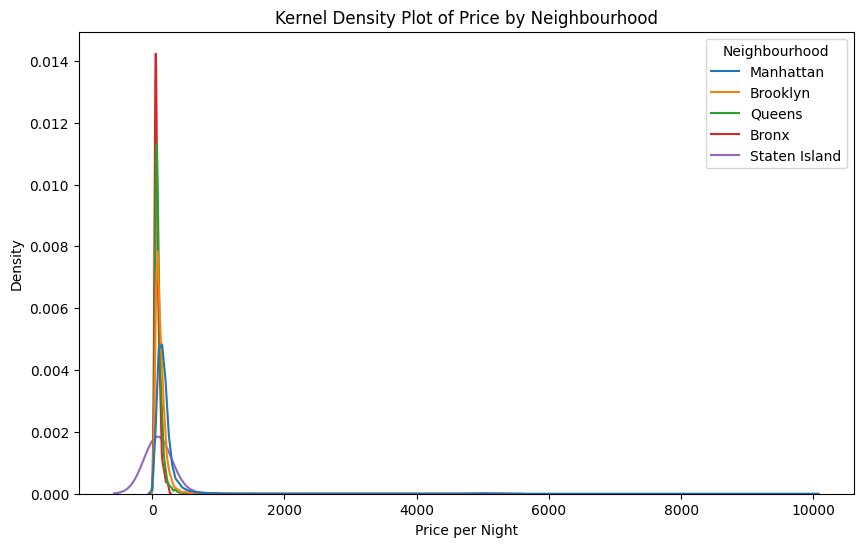

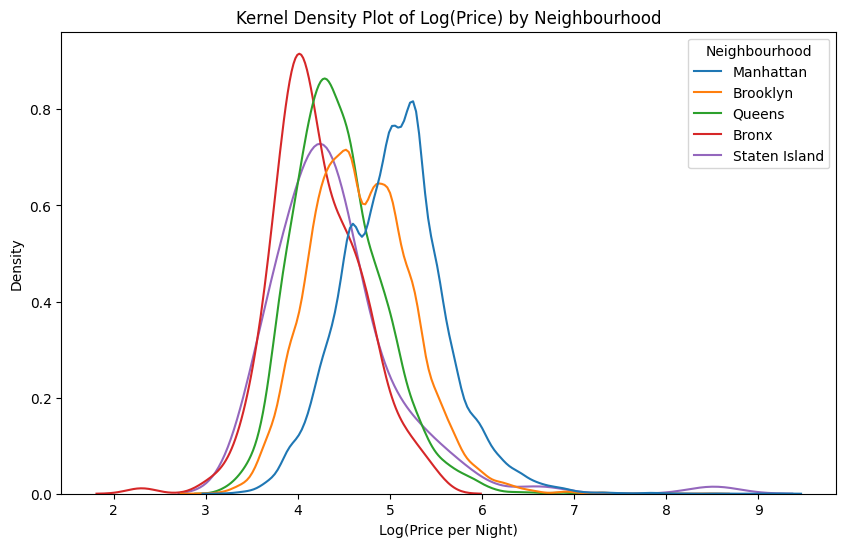

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Prices
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=airbnb,
    x="Price",
    hue="Neighbourhood",
    common_norm=False
)
plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.xlabel("Price per Night")
plt.ylabel("Density")
plt.show()

#Log Prices
airbnb["log_price"] = np.log(airbnb["Price"])

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=airbnb,
    x="log_price",
    hue="Neighbourhood",
    common_norm=False
)
plt.title("Kernel Density Plot of Log(Price) by Neighbourhood")
plt.xlabel("Log(Price per Night)")
plt.ylabel("Density")
plt.show()

The outliers in the regular kernel density plot make it difficult to extract any real information, so I wanted to redo it with outliers excluded.

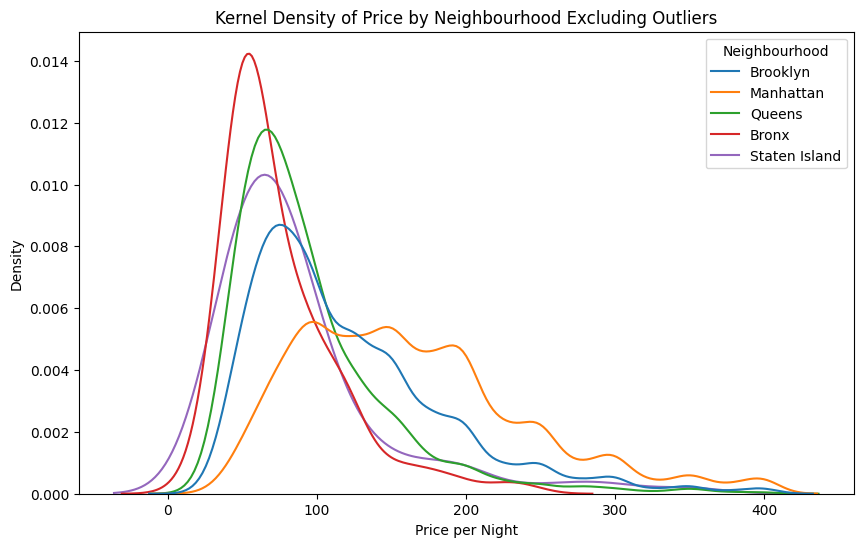

In [ ]:
price_limit = airbnb["Price"].quantile(0.97)

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=airbnb[airbnb["Price"] <= price_limit],
    x="Price",
    hue="Neighbourhood",
    common_norm=False
)
plt.title("Kernel Density of Price by Neighbourhood Excluding Outliers")
plt.xlabel("Price per Night")
plt.ylabel("Density")
plt.show()

##Question 2 - Part 2

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X_nb = pd.get_dummies(airbnb['Neighbourhood'], drop_first=True)
y = airbnb['Price']

model_nb = LinearRegression().fit(X_nb, y)
print(f"Intercept: {model_nb.intercept_:.2f}")
print(pd.Series(model_nb.coef_, index=X_nb.columns))

Intercept: 75.28
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


I chose to drop the first category, yielding the above results. This model takes the mean fom the dropped category (Bronx), and then computes the differences between the other boroughs. Adding the differences to the intercept, the following data is obtained.

 - Bronx: 75.28
 - Brooklyn: 75.28 + 52.47 = 127.75
 - Manhattan: 75.28 + 108.39 = 183.67
 - Queens: 75.28 + 21.58 = 96.86
 - Staten Island: 75.28 + 70.89 = 146.17

This matches table 1 exactly after the adjustment, which makes sense as this model is simply calculating the differences from the reference.

##Question 2 - Part 3

In [ ]:
y = airbnb['Price']
X_score = airbnb[['Review Scores Rating']]
model_score = LinearRegression().fit(X_score, y)
print(f"Intercept: {model_score.intercept_:.2f}")
print(f"Slope: {model_score.coef_[0]:.2f}")

Intercept: 60.88
Slope: 1.02


This linear model is comparing the relationship between price and review score. Since $y$ is price and $x$ is the review score, the equation is Price = 60.88 + 1.02(Review Score). Essentially, a review score of 0 would correlate to a price of 60.88.

##Question 2 - Part 4

In [ ]:
X_multi = pd.concat([X_nb, airbnb[['Review Scores Rating']]], axis=1)
model_multi = LinearRegression().fit(X_multi, y)
print(f"Rating Slope (Controlling for Location): {model_multi.coef_[-1]:.2f}")

model_4 = LinearRegression().fit(X_multi, airbnb['Price'])

print(f"\nNew Intercept (Baseline at 0 Rating): {model_4.intercept_:.2f}")

new_coeffs = pd.Series(model_4.coef_, index=X_multi.columns)
print("\nNew Borough Coefficients (Difference at 0 Rating):")
print(new_coeffs.drop('Review Scores Rating'))

Rating Slope (Controlling for Location): 1.08

New Intercept (Baseline at 0 Rating): -23.81

New Borough Coefficients (Difference at 0 Rating):
Brooklyn          51.704240
Manhattan        108.228737
Queens            21.694600
Staten Island     71.766552
dtype: float64


This new regression changes the slope by only comparing prices and ratings within a neighbourhood. This helps give a more accurate comparison between review score and price, because it is no longer affected by confusing inter-neighbourhood comparisons. For example, a very expensive Manhattan apartment would be compared to a cheap but higher rated apartment from the Bronx. This confuses the model, leading to a low slope which implies very little correlation between the two variables. However, within one neighbourhood, there isn't the wild variance in price, allowing actual correlation to be found, raising the slope to 1.08.

The Borough coefficients are also affected, as the boroughs are now compared to the refererences at the same review score. Initially, the model simply compared the means of all prices, but comparing prices at the same review score gives a more accurate analysis in comparing prices of similar quality properties. This leads to the resulting data above, with -23.81 being the price of a Bronx property with a rating of 0 (Negative because no review scores even come close to 0), and the coefficients being the difference in price also with a rating of 0. This yields the following changes:

Difference in coefficients:

 - Brooklyn: 52.47 - 51.70 = 0.77
 - Manhattan: 108.39 - 108.23 = 0.16
 - Queens: 21.58 - 21.69 = -0.11
 - Staten Island: 70.89 - 71.77 = -0.88


This means that, while Manhattan was $108.39$ dollars more expensive than the Bronx on average, it is only $108.23$ dollars more expensive at the same review score.

Looking at the trends, it seems that both Brooklyn and Manhattan are slightly higher rated in general than the Bronx, and Queens and Staten Island are slightly lower rated.

##Question 2 - Part 5

In [ ]:
boroughs = airbnb['Neighbourhood'].unique()

X_puzzle = pd.DataFrame()
for b in boroughs:
    X_puzzle[f'{b}'] = (airbnb['Neighbourhood'] == b).astype(int) * airbnb['Review Scores Rating']

X_puzzle['Constant'] = 1

model_puzzle = LinearRegression(fit_intercept=False).fit(X_puzzle, airbnb['Price'])

puzzle_results = pd.Series(model_puzzle.coef_, index=X_puzzle.columns)
print("The Puzzle: Separate Slopes per Neighborhood")
print(puzzle_results.to_string())

The Puzzle: Separate Slopes per Neighborhood
Manhattan         1.399376
Brooklyn          0.790947
Queens            0.456451
Bronx             0.222718
Staten Island     0.682444
Constant         55.118254


The constant here represents the baseline $0$ review score across all of New York. From this baseline, the slope represents how much the price of the airbnb rises per an increase in review score of 1. For example, a Manhattan apartment with a review score of 1 raises to $56.51$ dollars, whereas an airbnb in the Bronx only raises to $55.33$ dollars. Essentially, the greater the slope, the more money someone will pay for increased quality (review score). Manhattan has the highest premium for high quality, while people are less willing for play for premium airbnbs in the Bronx.

The major flaw with this model is it forces all of the boroughs into the same price for a review score of $0$. In reality, Manhattan would likely also be more expensive than the Bronx at a review score of $0$.

In summary, the slopes are not the same, with each borough charging vastly different amounts based on the review score.

##Question 2 - Part 6

To preface, this is part 6, and it is asking for the models in parts 4-6. I am slightly confused in what models this then means, so I am testing for the four models from parts 2-5.

In [ ]:
def get_rmse(X, y_data):
    mse_scores = cross_val_score(LinearRegression(), X, y_data, cv=10, scoring='neg_mean_squared_error')
    return np.sqrt(-mse_scores.mean())

print("10-Fold Cross Validation (RMSE):")
print(f"Model 2 (Location Only):    ${get_rmse(X_nb, y):.2f}")
print(f"Model 3 (Rating Only):      ${get_rmse(X_score, y):.2f}")
print(f"Model 4 (Parallel Slopes):  ${get_rmse(X_multi, y):.2f}")
print(f"Model 5 (The Puzzle):       ${get_rmse(X_puzzle, y):.2f}")

10-Fold Cross Validation (RMSE):
Model 2 (Location Only):    $145.54
Model 3 (Rating Only):      $148.64
Model 4 (Parallel Slopes):  $145.24
Model 5 (The Puzzle):       $145.15


The $10$-fold cross-validation reveals that Model 5 is the most accurate predictor of price, achieving the lowest RMSE of $145.15$ dollars.

While Model $2$ provides a strong baseline, adding Review Scores in Model $4$ and Model $5$ consistently reduced the error. The fact that Model $5$ outperformed Model $4$ suggests that the value of a higher review score is not uniform across New York, rather, the market places a different premium on quality depending on the neighborhood. However, the narrow margin between these models ($0.09) indicates that while quality matters, location remains the primary driver of price variance in this dataset.

Model $3$ is the least accurate because it attempts to predict price based on quality alone, ignoring the massive price variance caused by neighbourhood. The fact that Model $3$ has a higher RMSE than Model $2$ ($148.64$ vs $145.54$) proves that in this market, the  location of a property is a far more powerful predictor of price than the guest's satisfaction rating.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


##Question 3 - Part 1

Overall Price Summary:


,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


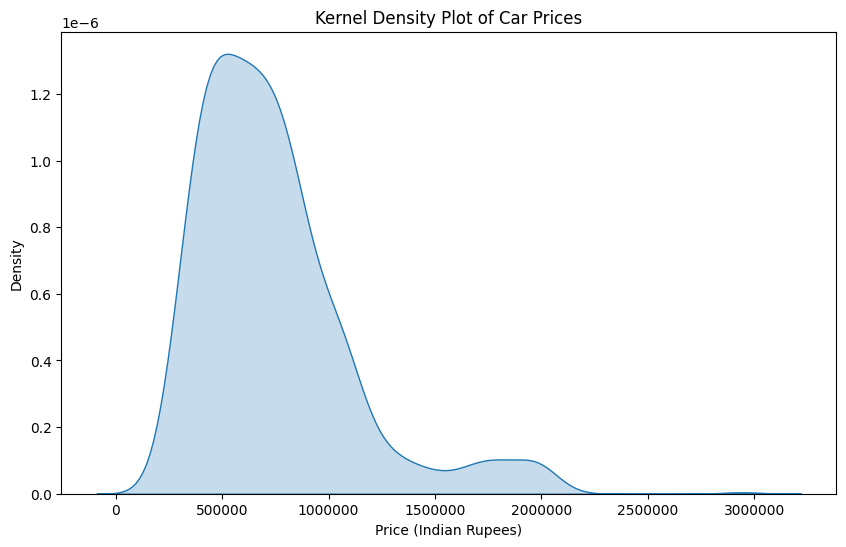

Price Summary by Body Type:


,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


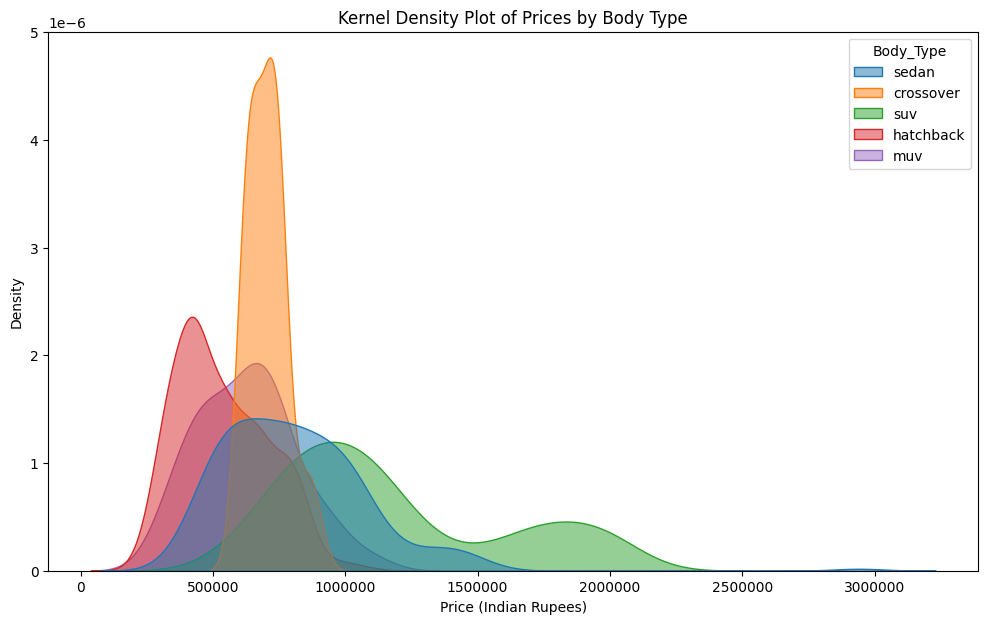

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cars = pd.read_csv("/content/data/cars_hw.csv")

print("Overall Price Summary:")
display((cars['Price'].describe()))
print("\n")

plt.figure(figsize=(10, 6))
sns.kdeplot(data=cars, x='Price', fill=True)
plt.title('Kernel Density Plot of Car Prices')
plt.xlabel('Price (Indian Rupees)')
plt.ylabel('Density')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

print("Price Summary by Body Type:")
body_type_summary = cars.groupby('Body_Type')['Price'].describe()
display((body_type_summary))

plt.figure(figsize=(12, 7))
sns.kdeplot(data=cars, x='Price', hue='Body_Type', fill=True, common_norm=False, alpha=0.5)
plt.title('Kernel Density Plot of Prices by Body Type')
plt.xlabel('Price (Indian Rupees)')
plt.ylabel('Density')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

On average, suvs tend to be the most expensive, however, the most expensive car in the data set is a sedan. Alternatively, hatchbacks are the cheapest cars by a considerable margin, with the cheapest individual car and mean car price. Suvs also have the most variance in this data with the highest standard deviation, almost double that of all the other car types. On the other hand, crossovers have by far the least amount of variance, with all of their cars falling in a range of ~$250,000$ Indian Rupees, and half within a range of just ~$110,000$ Indian Rupees.

##Question 3 - Part 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#Simple Regression

X1 = cars[['Seating_Capacity']]
y = cars['Price']

model1 = LinearRegression()
model1.fit(X1, y)

print(f"Model 1: Continuous")
print(f"Slope Coefficient: {model1.coef_[0]:.2f}")
print(f"Intercept: {model1.intercept_:.2f}\n")

#One Hot Encoded Variable

X2 = pd.get_dummies(cars['Seating_Capacity'], prefix='Seats', drop_first=True)

model2 = LinearRegression()
model2.fit(X2, y)

print(f"Model 2: Categorical")
print(f"Baseline Price (Intercept): {model2.intercept_:.2f}")

for col, coef in zip(X2.columns, model2.coef_):
    print(f"Price Difference for {col}: {coef:+.2f}")

Model 1: Continuous
Slope Coefficient: 59268.00
Intercept: 439032.01

Model 2: Categorical
Baseline Price (Intercept): 188000.00
Price Difference for Seats_5: +546483.87
Price Difference for Seats_6: +1456000.00
Price Difference for Seats_7: +735948.72
Price Difference for Seats_8: +271800.00


The slope coefficient from the first model is $59,268$ with an intercept of $439,032$. This implies that a $0$-seat car would be $439,032$ Rupees, and every added seat would result in a $59,268$ Rupee increase in price.

Compared to the linear format of model 1, model 2 actually isn't linear at all. Model 2 states that prices rise up until $6$-seater cars, and then fall again with $7$ and $8$-seater cars. This is likely because $6$ seat cars are often luxury vehicles, and increasing to $7$ or $8$ seats moves into the cheaper MUVs, designed for space but not luxury.

To better visualize this, the actual predicted prices can be seen in tables and graphs below.

Predicted Price Comparison Table:
 Seating Capacity  Model 1 (Continuous)  Model 2 (Categorical)
                4             676104.01              188000.00
                5             735372.01              734483.87
                6             794640.01             1644000.00
                7             853908.01              923948.72
                8             913176.01              459800.00


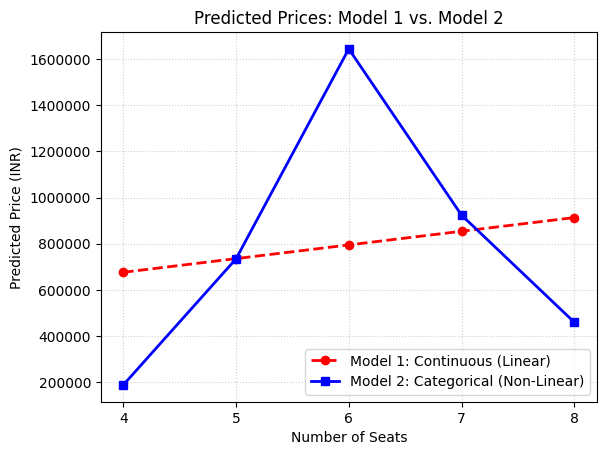

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Table Comparing Predicted Values
m1_slope = 59268.00
m1_intercept = 439032.01

m2_intercept = 188000.00
m2_coeffs = {4: 0, 5: 546483.87, 6: 1456000.00, 7: 735948.72, 8: 271800.00}

seats = [4, 5, 6, 7, 8]

m1_preds = [m1_intercept + (m1_slope * s) for s in seats]

m2_preds = [m2_intercept + m2_coeffs[s] for s in seats]

comparison_df = pd.DataFrame({
    'Seating Capacity': seats,
    'Model 1 (Continuous)': m1_preds,
    'Model 2 (Categorical)': m2_preds
})

print("Predicted Price Comparison Table:")
print(comparison_df.round(2).to_string(index=False))

# Comparison Plot
plt.plot(seats, m1_preds, label='Model 1: Continuous (Linear)',
         marker='o', linestyle='--', color='red', linewidth=2)

plt.plot(seats, m2_preds, label='Model 2: Categorical (Non-Linear)',
         marker='s', linestyle='-', color='blue', linewidth=2)

plt.title('Predicted Prices: Model 1 vs. Model 2')
plt.xlabel('Number of Seats')
plt.ylabel('Predicted Price (INR)')
plt.xticks(seats)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend();

This allows for a much easier to understand representation of the two models. Likely, model $2$ is far more accurate due to the drastic change in direction. I found it interesting that Model $1$ and Model $2$ agreed on the predicted price for $5$ seaters, and it made me think that maybe there is an overwhelming number of $5$-seater cars. This would "overpower" the linear model and cause it to focus primarily on the average price of 5-seater cars, makign it accurate to that number of seats but not others. Thinking about cars, this would also make sense as almost all $2$-row cars are $5$-seaters. I analyze this below.

In [ ]:
print("Count of Cars by Seating Capacity:")
display(cars['Seating_Capacity'].value_counts().sort_index())

Count of Cars by Seating Capacity:


,count
Seating_Capacity,
4,1
5,930
6,1
7,39
8,5


This confirms my suspicion that the data is dominated by $5$-seater cars (95%), essentially anchoring the linear model to the average price of $5$-seaters. This will significantly limit its predictive power for other seating capacities.

##Question 3 - Part 3

Degree 1 RMSE: 316694
Degree 2 RMSE: 317513
Degree 3 RMSE: 316828
Degree 4 RMSE: 316977
Degree 5 RMSE: 316435
Optimal Degree: 5


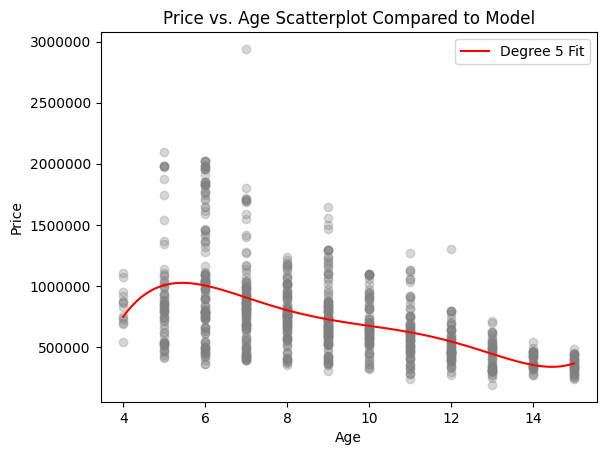

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

cars['Age'] = 2026 - cars['Make_Year']

best_rmse = float('inf')
best_degree = 1

for d in range(1, 6):
    X_poly = np.column_stack([cars['Age']**i for i in range(1, d + 1)])

    model = LinearRegression()
    mse_scores = cross_val_score(model, X_poly, cars['Price'], cv=10, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-mse_scores.mean())

    print(f"Degree {d} RMSE: {rmse:.0f}")
    if rmse < best_rmse:
        best_rmse = rmse
        best_degree = d

print(f"Optimal Degree: {best_degree}")

plt.scatter(cars['Age'], cars['Price'], alpha=0.3, color='gray')

X_final = np.column_stack([cars['Age']**i for i in range(1, best_degree + 1)])
model.fit(X_final, cars['Price'])

x_line = np.linspace(cars['Age'].min(), cars['Age'].max(), 100)
x_line_poly = np.column_stack([x_line**i for i in range(1, best_degree + 1)])
y_line = model.predict(x_line_poly)

plt.plot(x_line, y_line, color='red', label=f'Degree {best_degree} Fit')
plt.title('Price vs. Age Scatterplot Compared to Model'); plt.xlabel('Age'); plt.ylabel('Price'); plt.legend(); plt.ticklabel_format(style='plain', axis='y'); plt.show()

Originally, I iterated through degrees 1-11 to evaluate the optimal number of powers of Age. However, when using the determined optimal degree (7), the line appeared very "wiggly" and would randomly curve up and down. I assumed this meant that the high degree was causing overfitting, so I reduced the potential powers to 1-6. This achieved an optimal power of age as 5, and the line was much smoother, indicating less overfitting. As a result, it can be seen that the price of the cars decreases roughly linearly with age. Knowing that, in the real world, car value drops rapidly at first then smooths out, it is confusing to me that the price initially increases with age.

##Question 3 - Part 4

I accidentally answered this question in part 3 prior to reading this question, but will elaborate.

The model does accurately fit the patterns in the data because it follows the specific shape of the scatterplot points quite well. By using a or even a 5th-order polynomial, the red line is flexible enough to pass through the dense clusters of data, including that unusual "hump" where 5-year-old cars are more expensive than the newer ones. Since the 10-fold cross-validation picked this degree, we know it's mathematically proven to stay as close to data as possible. Essentially, the line does a good job of mirroring the actual price-to-age comparison found in this data.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


##Question 4 - Part 1

In [ ]:
import pandas as pd

df = pd.read_csv('/content/data/heart_hw.csv')


proportions = df.groupby('transplant')['y'].mean()

prop_control = proportions['control']

prop_treatment = proportions['treatment']

ate = prop_treatment - prop_control

print(f"Survival Proportion (Control): {prop_control:.4f}")
print(f"Survival Proportion (Treatment): {prop_treatment:.4f}")
print(f"Average Treatment Effect (ATE): {ate:.4f}")

Survival Proportion (Control): 0.1176
Survival Proportion (Treatment): 0.3478
Average Treatment Effect (ATE): 0.2302


This means that 11.76% of those who don't get the heart transplant survive for three years, whereas 34.78% of those who do get the transplant survive for three years. This means there is a 23.02% increase in survival likelihood given you receive the treatment (ATE).

##Question 4 - Part 2

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/data/heart_hw.csv')

df['transplant_numeric'] = df['transplant'].map({'control': 0, 'treatment': 1})

X = df[['transplant_numeric']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Intercept: {intercept:.4f}")
print(f"Transplant Coefficient: {coefficient:.4f}")

Intercept: 0.1176
Transplant Coefficient: 0.2302


When I regress y on transplant using a linear model, the resulting coefficients map directly to my previous calculations because the model is essentially calculating the mean survival for each group. The intercept represents the predicted value of survival when the transplant variable is zero (the control group), which is exactly 0.1176. The transplant coefficient represents the change in the predicted survival probability when moving from the control group to the treatment group (an increase from 0 to 1), which is exactly 0.2302, the ATE previously found. Mathematically, the model is given by the equation $prob = 0.1176 + 0.2302(\text{transplant})$, where the sum of the intercept and the coefficient ($0.1176 + 0.2302 = 0.3478$) equals the survival proportion for the treatment group. This demonstrates that a simple linear regression with a binary predictor is basically the same as comparing group means.

##Question 4 - Part 3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/data/heart_hw.csv')
df['transplant_numeric'] = df['transplant'].map({'control': 0, 'treatment': 1})

X_multi = df[['transplant_numeric', 'age']]
y = df['y']
model_multi = LinearRegression().fit(X_multi, y)

intercept = model_multi.intercept_
coef_transplant = model_multi.coef_[0]
coef_age = model_multi.coef_[1]

print(f"Intercept: {intercept:.4f}")
print(f"Transplant Coef (Adjusted): {coef_transplant:.4f}")
print(f"Age Coef: {coef_age:.4f}")

Intercept: 0.7020
Transplant Coef (Adjusted): 0.2647
Age Coef: -0.0136


When I controlled for age, the coefficient on the transplant increased from 0.2302 (Part 1 ATE) to 0.2647. This change is important because it shows that my original estimate was actually biased downward. By adding age to the regression, I accounted for the fact that age was a confounding variable. This is likely because older patients in this data have lower survival rates regardless of the transplant. Once the age effect was separated out, the true benefit of the transplant became more apparent, rising by about 3.45 percentage points.

The intercept of 0.7020 acts as the baseline, representing the predicted survival probability for a zero-year-old who didn't receive a transplant. The transplant coefficient of 0.2647 is my adjusted Average Treatment Effect (ATE), which tells me that when I hold age constant, getting a transplant boosts the predicted probability of survival by 26.47%. The age coefficient of -0.0136 shows that for every additional year of age, the survival probability drops by about 1.36%.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


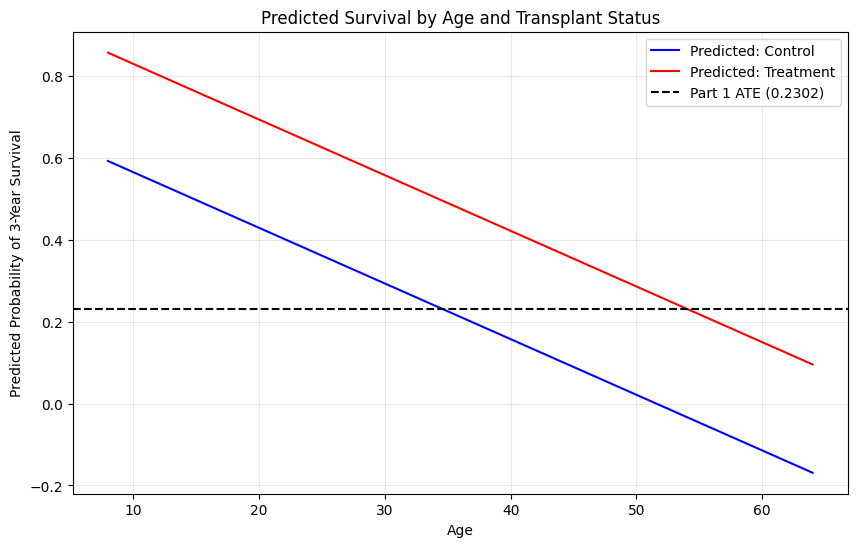

In [ ]:
age_range = np.linspace(df['age'].min(), df['age'].max(), 100).reshape(-1, 1)

pred_control = model_multi.predict(np.hstack([np.zeros_like(age_range), age_range]))
pred_treatment = model_multi.predict(np.hstack([np.ones_like(age_range), age_range]))

plt.figure(figsize=(10, 6))
plt.plot(age_range, pred_control, label='Predicted: Control', color='blue')
plt.plot(age_range, pred_treatment, label='Predicted: Treatment', color='red')

plt.axhline(y=0.2302, color='black', linestyle='--', label='Part 1 ATE (0.2302)')

plt.xlabel('Age')
plt.ylabel('Predicted Probability of 3-Year Survival')
plt.title('Predicted Survival by Age and Transplant Status')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Looking at my graph, the dashed line representing the Part 1 ATE (0.2302) acts as a fixed population average that doesn't account for how survival naturally drops with age. Because my regression lines have a negative slope, the ATE line serves as a reference for accuracy. For the treatment group, the ATE of 0.2302 underestimates the predicted survival for everyone younger than approximately 55 years old. Conversely, for patients older than 55, that same ATE overestimates their survival, as the age penalty in my model eventually drags their predicted probability below the 23% average.

##Question 4 - Part 4

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/data/heart_hw.csv')
df['transplant_numeric'] = df['transplant'].map({'control': 0, 'treatment': 1})

df['interaction'] = df['transplant_numeric'] * df['age']

X_inter = df[['transplant_numeric', 'age', 'interaction']]
y = df['y']
model_inter = LinearRegression().fit(X_inter, y)

b0 = model_inter.intercept_
b1 = model_inter.coef_[0]
b2 = model_inter.coef_[1]
b3 = model_inter.coef_[2]

print(f"Intercept: {b0:.4f}")
print(f"Transplant Coef: {b1:.4f}")
print(f"Age Coef: {b2:.4f}")
print(f"Interaction Coef: {b3:.4f}")

Intercept: 0.3549
Transplant Coef: 0.9078
Age Coef: -0.0055
Interaction Coef: -0.0146


In my new regression model, the inclusion of the interaction term changes how  the treatment's effectiveness is viewd. The intercept of 0.3549 is the baseline survival for the control group, while the transplant coefficient of 0.9078 now represents the starting benefit of the procedure for a zero-year-old. However, the interaction coefficient of -0.0146 is the most revealing part, teling me that for every year older a patient gets, the added survival benefit from the transplant shrinks by 1.46%. For example, at 5 years old, the transplant benfit would have shrunk by 7.3%, decreasing the benefit down to 83.48. This means the treatment is no longer a constant boost like it was in the previous model. Instead, its effectiveness actively fades as a patient ages.

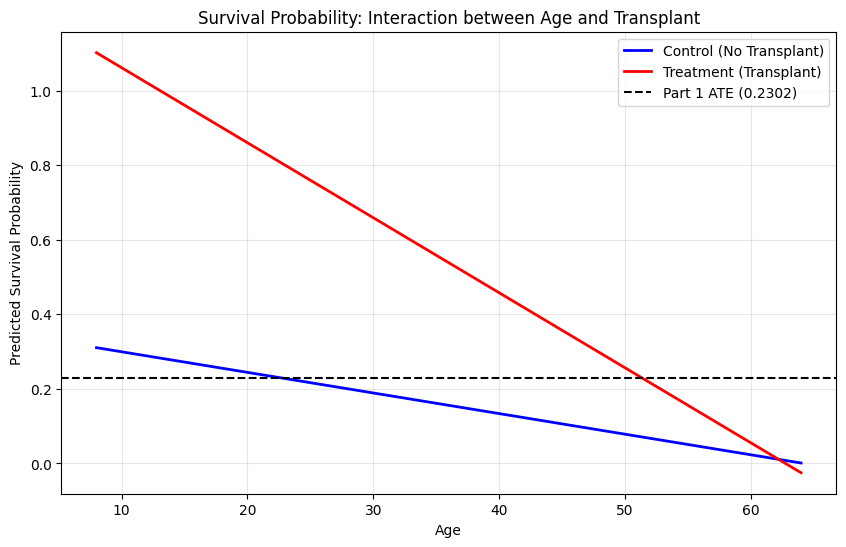

In [ ]:
ages = np.linspace(df['age'].min(), df['age'].max(), 100)
pred_control = b0 + (b2 * ages)
pred_treatment = b0 + b1 + (b2 * ages) + (b3 * ages)

plt.figure(figsize=(10, 6))
plt.plot(ages, pred_control, label='Control (No Transplant)', color='blue', lw=2)
plt.plot(ages, pred_treatment, label='Treatment (Transplant)', color='red', lw=2)
plt.axhline(y=0.2302, color='black', linestyle='--', label='Part 1 ATE (0.2302)')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.title('Survival Probability: Interaction between Age and Transplant')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The most important difference in the graph is that the two lines are no longer parallel, instead, they are converging. At younger ages, there is a massive vertical gap between the red treatment line and the blue control line, showing a high reward for the transplant. As age increases, the red line slopes downward much more aggressively than the blue line, causing the gap to narrow until the two lines actually cross over around age 62. At that point, the model suggests the transplant provides no additional benefit, and may even be associated with a lower predicted survival than the control.

##Question 4 - Part 5

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

df = pd.read_csv('/content/data/heart_hw.csv')
df['transplant_num'] = df['transplant'].map({'control': 0, 'treatment': 1})
df['interaction'] = df['age'] * df['transplant_num']
y = df['y']

models = {
    "Model 1 (Transplant)": df[['transplant_num']],
    "Model 2 (Transplant + Age)": df[['transplant_num', 'age']],
    "Model 3 (Interaction)": df[['transplant_num', 'age', 'interaction']]
}

for name, X in models.items():
    scores = cross_val_score(LinearRegression(), X, y, cv=10, scoring='neg_mean_squared_error')
    avg_mse = -scores.mean()
    print(f"{name} Average MSE: {avg_mse:.4f}")

Model 1 (Transplant) Average MSE: 0.2097
Model 2 (Transplant + Age) Average MSE: 0.1992
Model 3 (Interaction) Average MSE: 0.1961


The Mean Squared Error (MSE) decreased with each model, showing that adding age and the interaction term improved the model's predictive accuracy. Since Model 3 has the lowest Average MSE of 0.1961, it is the most accurate of the three at predicting survival probabilities in this dataset.

##Question 4 - Part 6

  1. The biggest issue is that both Model 2 and Model 3 include a negative coefficient for age, which creates a bias against older patients in a clinical prioritization setting. Because the model predicts lower survival for older individuals, a logic focused solely on maximizing survival probability would naturally divert organs away from the elderly and toward the young. This raises the ethical question of whether a 60-year-old be should be denied a transplant simply because a 20-year-old has a mathematically higher predicted probability of success.

  2. Additionally, the functional flaws of the Linear Probability Model make it a poor tool for this kind of high-stakes decision-making. As the graphs show, model 3 predicts impossible survival probabilities, reaching over 100% for children and dropping below 0% for some older adults. If this were deployed, it might incorrectly suggest that a transplant is useless for a 65-year-old simply because the linear slope hit zero, even if the actual clinical reality is much more complex.

  3. Finally, the model suffers from significant omitted variable bias because it only considers age and transplant status. In reality, transplant success depends on dozens of other factors like genetic matching, post-operative care, and many other factors. By ignoring these, the model might be attributing survival outcomes to age when they are actually driven by other health or lifestyle variables. Prioritizing based on such a limited snapshot could lead to deeply unfair outcomes where a healthy older patient is de-prioritized simply because the model only sees their birth year rather than their overall clinical profile.